In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from  torch.utils.data import DataLoader
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import numpy as np
from scipy.stats import norm

In [2]:
import sys
sys.path.append('.')

In [105]:
from funs.SineWave_Dataset import SineWave_DataSet
from funs.scheduler import noise_scheduler, add_noise_onestep, add_noise_from_zero, add_noise_onestep_cum_sampler, ddpm_sampler
from funs.plotting import plot_batched_lines, animate_forward_noise, animate_reverse_process
from funs.unet_1d import ConditionalUNet1D
from funs.time_embedding import get_sinusoidal_table


In [66]:
ds = SineWave_DataSet(freq_max = 5)
sample = ds[0]
sample_freq = sample[0]
sample_freq

tensor([3.4505])

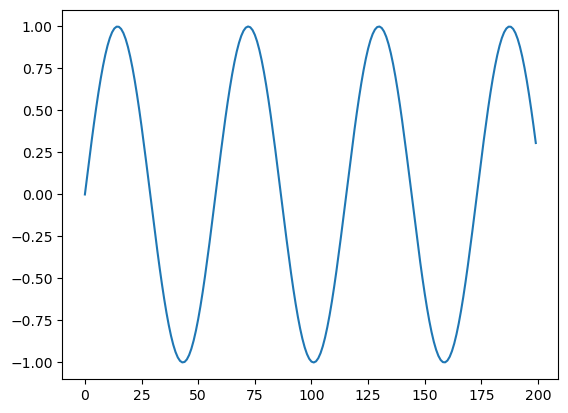

In [67]:

data = sample[1]
plt.plot(data)

In [80]:
schedules = noise_scheduler(beta_min = 1e-4, beta_max = 0.02, T = 500)

Adopting a linear scheduler


In [81]:
schedules.keys()

dict_keys(['betas', 'alphas', 'alpha_hats', 'alpha_hats_sqrt', 'one_minus_alpha_hats_sqrt', 'posterior_variance'])

In [82]:
schedules['betas'].shape, schedules['alphas'].shape, schedules['alpha_hats'].shape, schedules['alpha_hats_sqrt'].shape, schedules['one_minus_alpha_hats_sqrt'].shape, schedules['posterior_variance'].shape

(torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]))

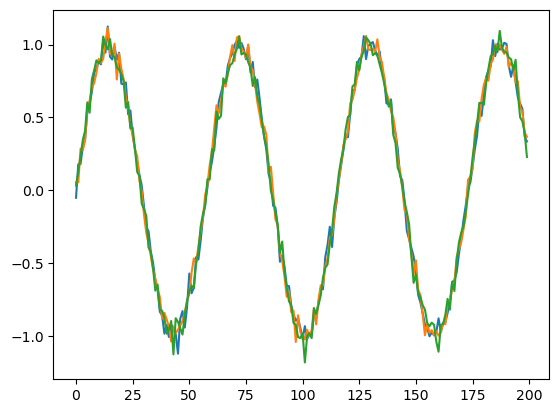

In [100]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 10, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 10, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 10, scheduler_dict = schedules, no_samples = 1))


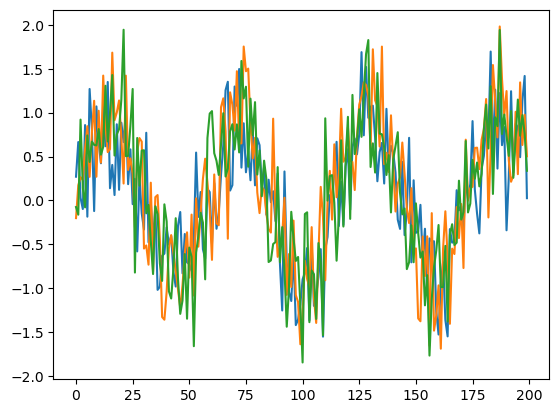

In [101]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 100, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 100, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 100, scheduler_dict = schedules, no_samples = 1))

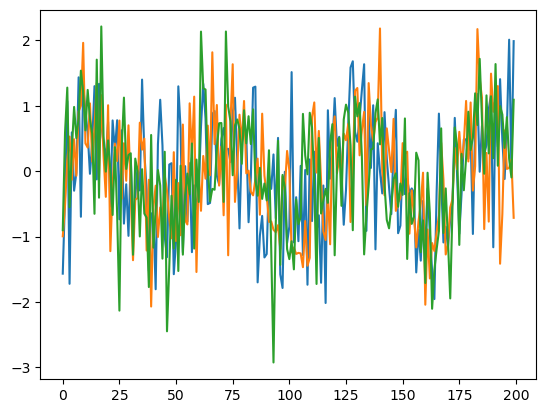

In [102]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 200, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 200, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 200, scheduler_dict = schedules, no_samples = 1))


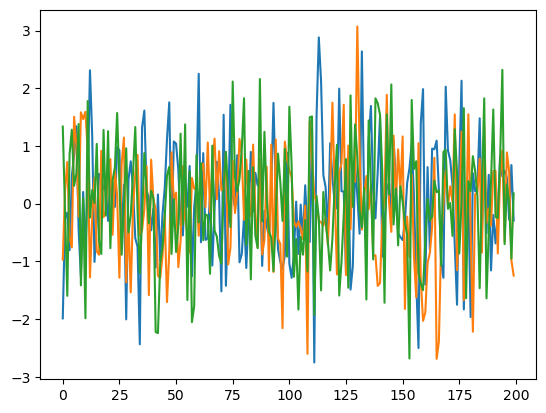

In [103]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 400, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 400, scheduler_dict = schedules, no_samples = 1)); plt.plot(add_noise_onestep_cum_sampler(data, t = 400, scheduler_dict = schedules, no_samples = 1))


In [124]:
unconditional_model = ConditionalUNet1D(in_channels= 1, base_channels= 64, t_steps= 500, t_dim= 64, cond_dim= 1, emb_dim= 72)
x_t_dummy = torch.randn(12, 1, 200)
t_dummy = torch.randint(1, 499, (12,))
x_cond = torch.randn(12, 1)
unconditional_model(x_t_dummy, t_dummy, None).shape

torch.Size([12, 1, 200])

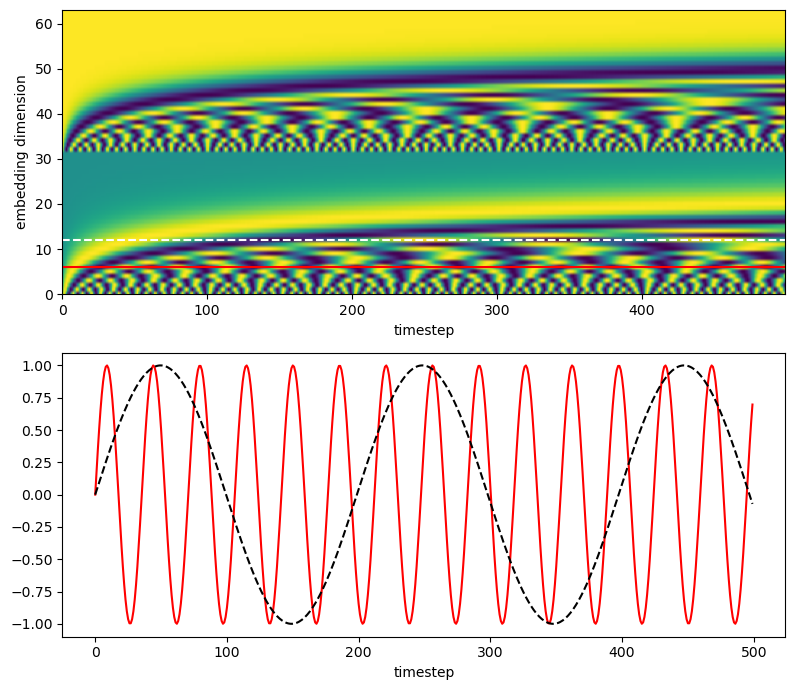

In [125]:

time_embedding_table = get_sinusoidal_table(500, 64)
fig, ax = plt.subplots(2, 1, figsize=(8, 7))  # (width, height) in inches

im = ax[0].imshow(time_embedding_table.T,aspect="auto",origin="lower",cmap="viridis")
ax[0].axhline(y = [6], color = "red")
ax[0].axhline(y = [12], color = "white", linestyle = '--')


ax[0].set_xlabel("timestep")
ax[0].set_ylabel("embedding dimension")
ax[0].set_xlim(0, time_embedding_table.shape[0] - 1)     # x-axis is timestep index
ax[0].set_ylim(0, time_embedding_table.shape[1] - 1)     # y-axis is embedding dim index

ax[1].plot(time_embedding_table[:,6], color = 'red')
ax[1].plot(time_embedding_table[:,12],color = 'black', linestyle = '--')
ax[1].set_xlabel("timestep")

plt.tight_layout()

plt.show()